<a href="https://colab.research.google.com/github/javendaXgh/ucveconomiaestadistica1/blob/main/notebooks/laboratorio_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estadística I, Laboratorio 3

## Temas:
### Números índices
- Índice simple: Mide el cambio individual de cada precio respecto al período base.
- Índice agregado simple: Compara el promedio de precios en distintos períodos, sin ponderar por cantidades.
- Índice agregado ponderado de Laspeyres: Usa cantidades del período base para ponderar precios. Tiende a sobreestimar el aumento del costo de vida.
- Índice agregado ponderado de Paasche: Usa cantidades actuales, reflejando sustitución de bienes. Tiende a subestimar el aumento del costo de vida.



### Series de Tiempo

In [ ]:
install.packages('')

In [2]:
library(ggplot2)
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [9]:
# Simulación de datos de precios
precios <- data.frame(
  Bien = c("Arroz", "Carne", "Transporte", "Medicina", "Educacion"),
  P0 = c(2.5, 5.0, 1.2, 3.0, 4.5),   # Precios en período base
  P1 = c(3.0, 5.5, 1.3, 3.5, 4.8),   # Precios en período 1
  P2 = c(3.2, 6.0, 1.4, 3.4, 5.2)    # Precios en período 2
)

In [10]:
precios

Bien,P0,P1,P2
<chr>,<dbl>,<dbl>,<dbl>
Arroz,2.5,3.0,3.2
Carne,5.0,5.5,6.0
Transporte,1.2,1.3,1.4
Medicina,3.0,3.5,3.4
Educacion,4.5,4.8,5.2


Vamos a signar las cantidades consumidas para cada bien o servicio en el período base:

1- arroz: 10 unidades

2- carne: 8 unidades

3- transporte: 15 pasajes

4- medicina: 6 unidades

5- Educacion: 4 unidades crédito

Lo mismo se define para otros dos períodos en `cantidades_1` y  `cantidades_2`


In [12]:
# Cantidades base (para índices ponderados)
cantidades_base <- c(10, 8, 15, 6, 4)

# Cantidades actuales (para Paasche)
cantidades_1 <- c(9, 8, 16, 5, 5)
cantidades_2 <- c(8, 7, 18, 6, 6)

In [13]:
# Agregamos las cantidades al dataframe
precios$Q0 <- cantidades_base
precios$Q1 <- cantidades_1
precios$Q2 <- cantidades_2

Revisar la nueva data frame con todos los datos de interés

In [14]:
precios

Bien,P0,P1,P2,Q0,Q1,Q2
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Arroz,2.5,3.0,3.2,10,9,8
Carne,5.0,5.5,6.0,8,8,7
Transporte,1.2,1.3,1.4,15,16,18
Medicina,3.0,3.5,3.4,6,5,6
Educacion,4.5,4.8,5.2,4,5,6


### Cálcular Índice Simple

In [22]:
# crear la nueva data frame en la que mostraremos el índice simple
indice_simple <- precios[, c("Bien", "P0", "P1", "P2")]
indice_simple

Bien,P0,P1,P2
<chr>,<dbl>,<dbl>,<dbl>
Arroz,2.5,3.0,3.2
Carne,5.0,5.5,6.0
Transporte,1.2,1.3,1.4
Medicina,3.0,3.5,3.4
Educacion,4.5,4.8,5.2


**¿Cómo calcularíamos el índice simple para el período 1? mediante el operador $ insertamos una columna nueva**

In [29]:
indice_simple$I_Simple_01 <- indice_simple$P1/indice_simple$P0


indice_simple

Bien,P0,P1,P2,I01,I_Simple_01,I_Simple_02
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Arroz,2.5,3.0,3.2,1.200000,1.200000,1.280000
Carne,5.0,5.5,6.0,1.100000,1.100000,1.200000
Transporte,1.2,1.3,1.4,1.083333,1.083333,1.166667
Medicina,3.0,3.5,3.4,1.166667,1.166667,1.133333
Educacion,4.5,4.8,5.2,1.066667,1.066667,1.155556


**y para el período 2?**

In [28]:
indice_simple$I_Simple_02 <- indice_simple$P2/indice_simple$P0

indice_simple

Bien,P0,P1,P2,I01,I_Simple_01,I_Simple_02
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Arroz,2.5,3.0,3.2,1.200000,1.200000,1.280000
Carne,5.0,5.5,6.0,1.100000,1.100000,1.200000
Transporte,1.2,1.3,1.4,1.083333,1.083333,1.166667
Medicina,3.0,3.5,3.4,1.166667,1.166667,1.133333
Educacion,4.5,4.8,5.2,1.066667,1.066667,1.155556


### ejercicio a realizar
Calcular la variación por entre periodo 1 y 2 en una nueva columna

### Índice Agregado Simple

In [33]:
# ---- ÍNDICE AGREGADO SIMPLE ----

# Suma de precios en cada periodo dividido por la suma del período base
I_agregado_simple_01 <- sum(precios$P1) / sum(precios$P0)

I_agregado_simple_01

[1] 1.117284

In [35]:
# ---- ÍNDICE AGREGADO SIMPLE ----
# Suma de precios en cada periodo dividido por la suma del período base
I_agregado_simple_02 <- sum(precios$P2) / sum(precios$P0)
round(I_agregado_simple_02,2)

[1] 1.19

### ÍNDICE AGREGADO PONDERADO LASPEYRES

fórmula = Σ P1 * Q0 / Σ P0 * Q0

In [41]:
# (Σ P1*Q0) / (Σ P0*Q0)
sum(precios$P1 * precios$Q0) # numerador de la fórmula (Σ P1*Q0)
sum(precios$P0 * precios$Q0) # denominador de la formula (Σ P0*Q0)
sum(precios$P1 * precios$Q0) / sum(precios$P0 * precios$Q0) # resultado
round(sum(precios$P1 * precios$Q0) / sum(precios$P0 * precios$Q0) , 2) # redondear

[1] 133.7

[1] 119

[1] 1.123529

[1] 1.12

In [42]:
I_laspeyres_01 <- sum(precios$P1 * precios$Q0) / sum(precios$P0 * precios$Q0) # asignar a  I_laspeyres_01 el resultado período 1
I_laspeyres_02 <- sum(precios$P2 * precios$Q0) / sum(precios$P0 * precios$Q0) # asignar a  I_laspeyres_02 el resultado período 2

In [43]:
cat("Período 1 vs base:", round(I_laspeyres_01, 2), "\n")
cat("Período 2 vs base:", round(I_laspeyres_02, 2), "\n")

Período 1 vs base: 1.12 
Período 2 vs base: 1.19 


### ÍNDICE AGREGADO PONDERADO PAASCHE

fórmula = Σ P1 * Q1 / Σ P0 * Q1

In [44]:

# (Σ P1*Q1) / (Σ P0*Q1)
I_paasche_01 <- sum(precios$P1 * precios$Q1) / sum(precios$P0 * precios$Q1)
I_paasche_02 <- sum(precios$P2 * precios$Q2) / sum(precios$P0 * precios$Q2)


In [45]:
cat("Período 1 vs base:", round(I_paasche_01, 3), "\n")
cat("Período 2 vs base:", round(I_paasche_02, 3), "\n")

Período 1 vs base: 1.118 
Período 2 vs base: 1.188 


### Series de Temporales
#### Ejemplo 1: producción de petróleo Venezuela-Colombia

In [46]:
# cargar datos
prod_petroleo = read.csv('https://raw.githubusercontent.com/javendaXgh/ucveconomiaestadistica1/refs/heads/main/data/producion_petroleo.csv')

In [47]:
prod_petroleo

Entity,Year,produccion,produccionK
<chr>,<int>,<int>,<dbl>
Colombia,1970,11619000,11619.00
Colombia,1971,11413000,11413.00
Colombia,1972,10403000,10403.00
Colombia,1973,9737000,9737.00
Colombia,1974,8910000,8910.00
Colombia,1975,8311000,8311.00
Colombia,1976,7747000,7747.00
Colombia,1977,7089000,7089.00
Colombia,1978,6739000,6739.00


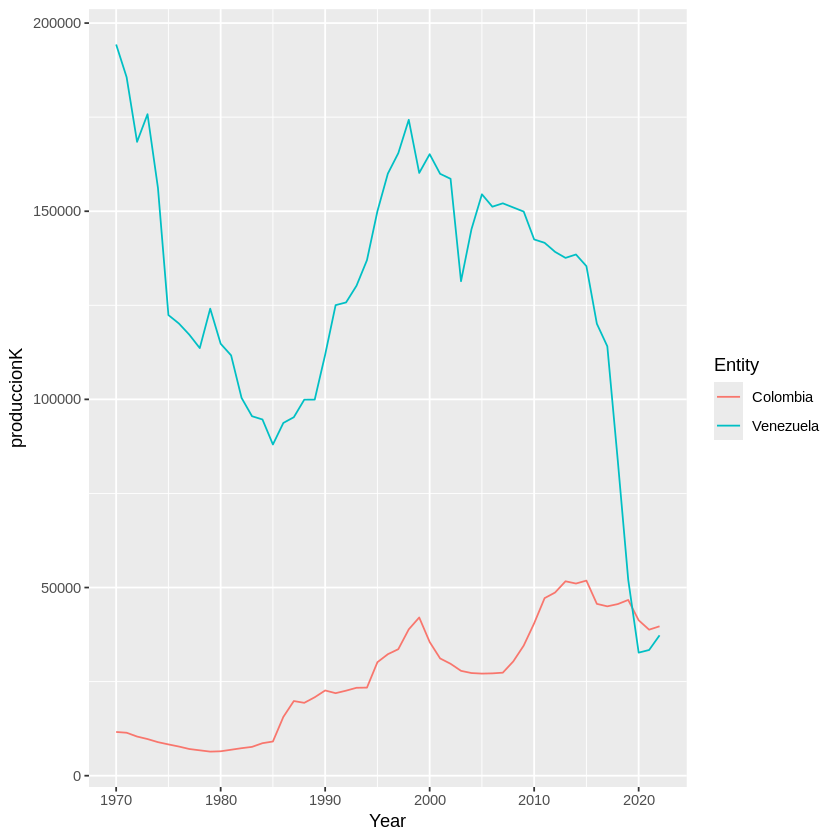

In [48]:
ggplot(prod_petroleo,aes(x=Year,
                              y=produccionK,
                              color=Entity ))+
  geom_line()

#### Ejemplo 2: valor apple

In [50]:
# cargar datos
df_valor_apple = read.csv('https://raw.githubusercontent.com/javendaXgh/ucveconomiaestadistica1/refs/heads/main/data/df_valor_apple.csv')

In [51]:
df_valor_apple

fecha,AAPL.close,variacion_precio,AAPL.volume,mes,year,dia,mes_year
<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<chr>
2021-01-04,129.41,0.9752807,143301900,1,2021,4,1-2021
2021-01-05,131.01,1.0123637,97664900,1,2021,5,1-2021
2021-01-06,126.60,0.9663385,155088000,1,2021,6,1-2021
2021-01-07,130.92,1.0341232,109578200,1,2021,7,1-2021
2021-01-08,132.05,1.0086313,105158200,1,2021,8,1-2021
2021-01-11,128.98,0.9767512,100384500,1,2021,11,1-2021
2021-01-12,128.80,0.9986045,91951100,1,2021,12,1-2021
2021-01-13,130.89,1.0162267,88636800,1,2021,13,1-2021
2021-01-14,128.91,0.9848728,90221800,1,2021,14,1-2021


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


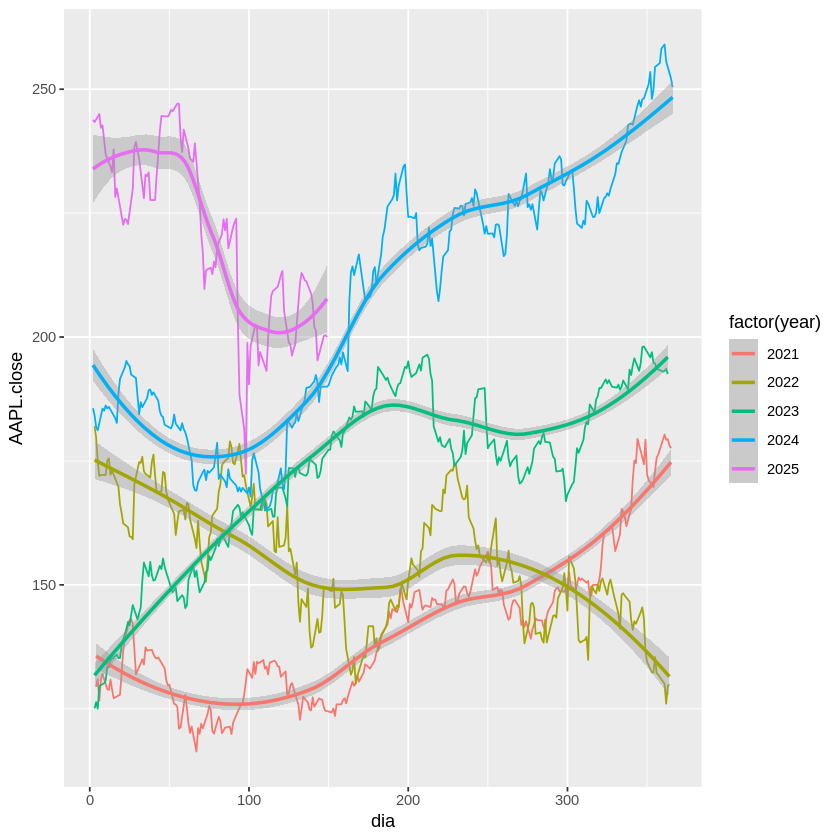

In [55]:
ggplot(df_valor_apple,
       aes(x=dia,
           y=AAPL.close,
           color=factor(year)))+
  geom_line()+
  geom_smooth()


### Ejercicio:
Identificar los siguientes compomentes visualmente


-   **Tendencia**: dirección general a largo plazo.

-   **Estacionalidad**: patrones repetitivos dentro de un período fijo.

-   **Ciclicidad**: ondulaciones de mayor duración.

-   **Aleatoriedad**: fluctuaciones irregulares.